# Authors
- Raphael Wäspi ()
- Nicolas Huber (16-936-205)

## Clustering Coefficient - Coding Exercise (6 points)

For the provided datasets (you can find the dataset files in the Materials/Session 03 folder on OLAT):

1. Plot the average degree of the nearest neighbours knn as a function of the vertices degree.
2. Super impose the same quantity for the randomised network.
Hint: The randomised networks are obtained via multiple edge swaps via the networkx function
nx.algorithms.smallworld.random_reference. Make sure to set the parameter connectivity
= False to have faster execution. If execution is still slow, we provide randomised datasets.)
3. Compute the assortativity coefficient of the real network.
4. Compute the assortativity coefficient of the randomised network.

In [23]:
# Imports
import match as m
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
from tqdm import tqdm

### 1. Plot the average degree of the nearest neighbours knn as a function of the vertices degree.

In [38]:
# Define the directory containing the .gml files
directory = 'assignment_1_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading GML Files:  22%|██▏       | 2/9 [00:09<00:26,  3.77s/it]

Finished loading graph_AstroPh
Finished loading graph_jazz_collab


Loading GML Files:  56%|█████▌    | 5/9 [00:14<00:07,  2.00s/it]

Finished loading graph_internet
Finished loading graph_game_thrones
Finished loading graph_eu_airlines


...

Finished loading graph_facebook


Loading GML Files:  89%|████████▉ | 8/9 [00:29<00:03,  3.74s/it]

Finished loading graph_CondMat


Loading GML Files: 100%|██████████| 9/9 [00:31<00:00,  3.51s/it]

Finished loading graph_chess


In [42]:
results = dict.fromkeys(graphs)
for key, value in results.items():
    results[key] = {}

In [43]:
print(results)

{'graph_AstroPh': {}, 'graph_jazz_collab': {}, 'graph_internet': {}, 'graph_game_thrones': {}, 'graph_eu_airlines': {}, 'graph_celegansInteractomes': {}, 'graph_facebook': {}, 'graph_CondMat': {}, 'graph_chess': {}}


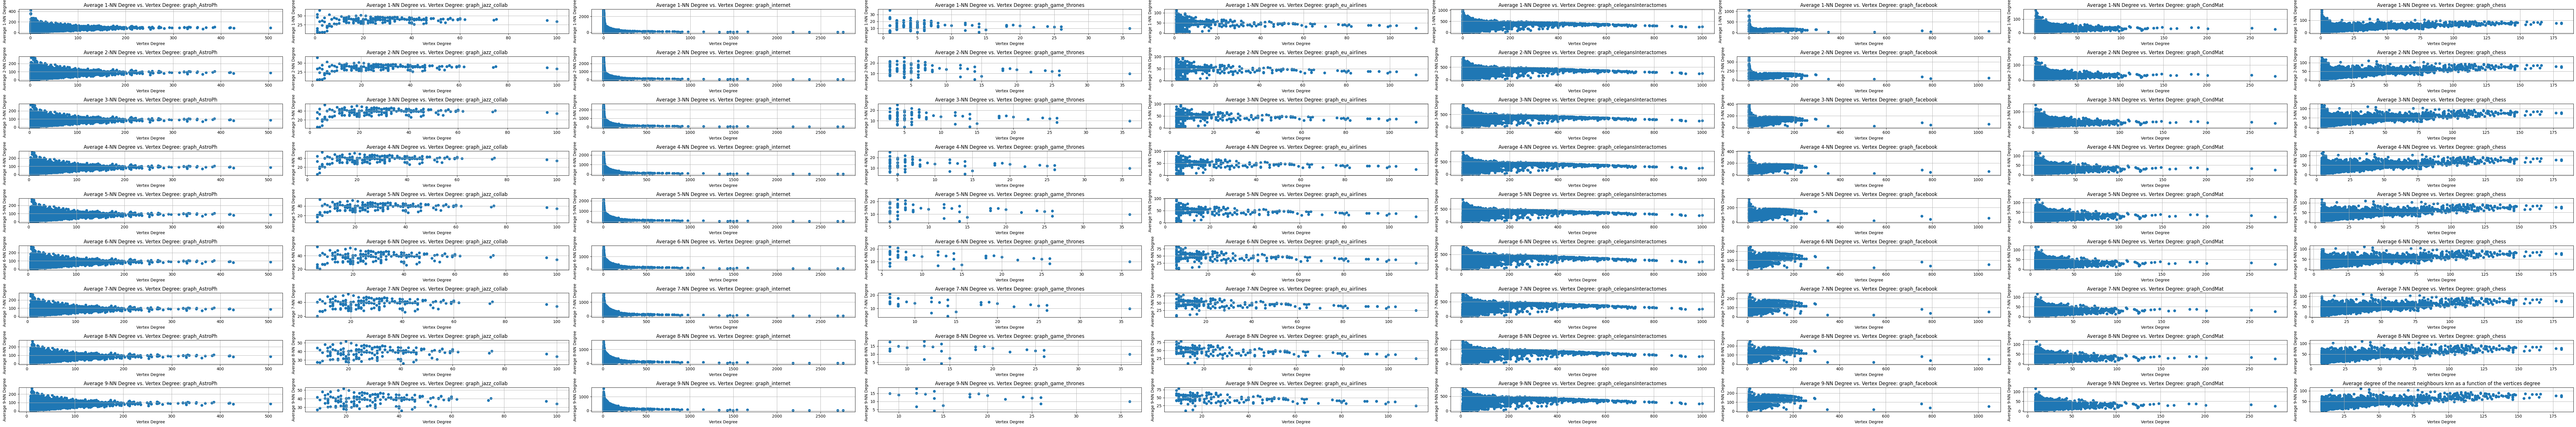

In [71]:
max_k = 10

num_graphs = len(graphs)

# Create a grid of subplots with rows for each k value and columns for each graph
fig, axs = plt.subplots(max_k - 1, num_graphs, figsize=(90, 15))

for k in range(1, max_k):
    for i, (graph_name, g) in enumerate(graphs.items()):
        average_knn_degrees = []
        node_degrees = []
        
        # Iterate over all nodes and extract neighbors
        
        for node in g.nodes():
            neighbors = list(g.neighbors(node))
            # calculate degrees for all neighbors and also the average knn degree
            if len(neighbors) >= k:
                # x-value 
                node_degrees.append(len(neighbors))
                
                # y-value
                knn_degrees = [g.degree(neighbor) for neighbor in neighbors]
                average_knn_degree = np.mean(knn_degrees)
                average_knn_degrees.append(average_knn_degree) 
                
        
        
        # Append to result dict
        results[graph_name][f"Average {k}-NN Degree"] = average_knn_degrees
        
        # Plot on the corresponding subplot
        axs[k - 1, i].scatter(x=node_degrees, y=average_knn_degrees)
        axs[k - 1, i].set_xlabel("Vertex Degree")
        axs[k - 1, i].set_ylabel(f"Average {k}-NN Degree")
        axs[k - 1, i].set_title(f"Average {k}-NN Degree vs. Vertex Degree: {graph_name}")
        axs[k - 1, i].grid(True)
 
# Adjust spacing between subplots
plt.title(label="Average degree of the nearest neighbours knn as a function of the vertices degree", loc="center")
plt.tight_layout()
plt.show()


       